# Titanic - Exploratory Data Analysis (EDA)

Converted from `titanic_eda.py`. Run cells in order; each section reproduces the printed stats and plots from the original script.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## SETTINGS

In [2]:
FILE_PATH = "train.csv"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## HELPER FUNCTIONS

In [3]:
def section(title):
    print("\n" + "=" * 75)
    print(title)
    print("=" * 75)


def show_plot():
    plt.tight_layout()
    plt.show()

## 1. LOAD DATA

In [4]:
df = pd.read_csv(FILE_PATH)

section("TITANIC DATASET - EXPLORATORY DATA ANALYSIS")

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nFirst 5 rows:")
print(df.head())


TITANIC DATASET - EXPLORATORY DATA ANALYSIS
Rows: 891
Columns: 12

First 5 rows:
   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         0       3  ...   7.2500   NaN         S
1            2         1       1  ...  71.2833   C85         C
2            3         1       3  ...   7.9250   NaN         S
3            4         1       1  ...  53.1000  C123         S
4            5         0       3  ...   8.0500   NaN         S

[5 rows x 12 columns]


## 2. DATASET OVERVIEW

In [5]:
section("1. DATASET OVERVIEW")

print("\nData types:")
print(df.dtypes)

print("\nDescriptive statistics:")
print(df.describe())

print("\nDuplicate rows:", df.duplicated().sum())


1. DATASET OVERVIEW

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

Descriptive statistics:
       PassengerId    Survived      Pclass  ...       SibSp       Parch        Fare
count   891.000000  891.000000  891.000000  ...  891.000000  891.000000  891.000000
mean    446.000000    0.383838    2.308642  ...    0.523008    0.381594   32.204208
std     257.353842    0.486592    0.836071  ...    1.102743    0.806057   49.693429
min       1.000000    0.000000    1.000000  ...    0.000000    0.000000    0.000000
25%     223.500000    0.000000    2.000000  ...    0.000000    0.000000    7.910400
50%     446.000000    0.000000    3.000000  ...    0.000000    0.000000   14.454200
75%     668.500000    1.000000    3.000000  ...    1.000000    

## 3. MISSING VALUES


2. MISSING VALUE ANALYSIS

Missing values:
Cabin: 687 (77.1%)
Age: 177 (19.9%)
Embarked: 2 (0.2%)

INSIGHT:
Cabin has the largest amount of missing data, followed by Age. Embarked has only a very small number of missing observations. Missing values should be considered before further analysis or machine-learning modeling.


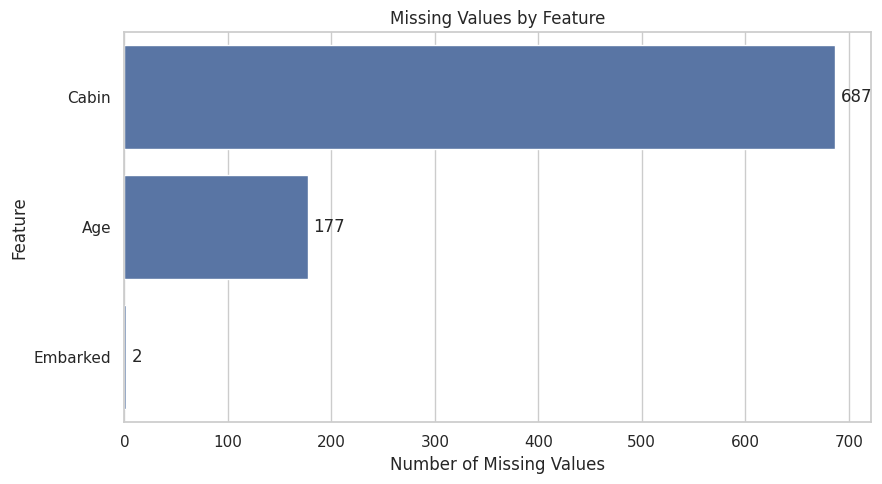

In [6]:
section("2. MISSING VALUE ANALYSIS")

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("\nMissing values:")
for column, count in missing.items():
    print(f"{column}: {count} ({count / len(df) * 100:.1f}%)")

plt.figure()
ax = sns.barplot(x=missing.values, y=missing.index)

plt.title("Missing Values by Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature")

for i, value in enumerate(missing.values):
    ax.text(value + 5, i, str(value), va="center")

show_plot()

print("\nINSIGHT:")
print(
    "Cabin has the largest amount of missing data, followed by Age. "
    "Embarked has only a very small number of missing observations. "
    "Missing values should be considered before further analysis "
    "or machine-learning modeling."
)

## 4. SURVIVAL DISTRIBUTION


3. SURVIVAL DISTRIBUTION
Did not survive: 549
Survived: 342
Overall survival rate: 38.4%

INSIGHT:
38.4% of passengers survived, while 61.6% did not survive. This is the baseline survival distribution used to compare other passenger characteristics.


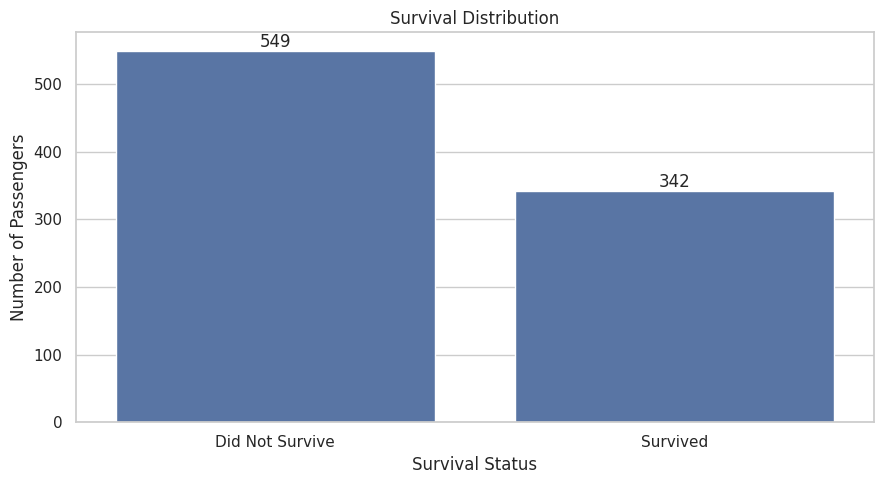

In [7]:
section("3. SURVIVAL DISTRIBUTION")

survival_counts = df["Survived"].value_counts().sort_index()
survival_rate = df["Survived"].mean()

print(f"Did not survive: {survival_counts.get(0, 0)}")
print(f"Survived: {survival_counts.get(1, 0)}")
print(f"Overall survival rate: {survival_rate * 100:.1f}%")

plt.figure()
ax = sns.countplot(data=df, x="Survived")

plt.title("Survival Distribution")
plt.xlabel("Survival Status")
plt.ylabel("Number of Passengers")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])

for container in ax.containers:
    ax.bar_label(container)

show_plot()

print("\nINSIGHT:")
print(
    f"{survival_rate * 100:.1f}% of passengers survived, while "
    f"{(1 - survival_rate) * 100:.1f}% did not survive. "
    "This is the baseline survival distribution used to compare "
    "other passenger characteristics."
)

## 5. GENDER DISTRIBUTION


4. GENDER DISTRIBUTION
Sex
male      577
female    314
Name: count, dtype: int64

INSIGHT:
There are more male than female passengers in the dataset. Passenger counts alone do not tell us whether gender is associated with survival, so survival rates must be compared.


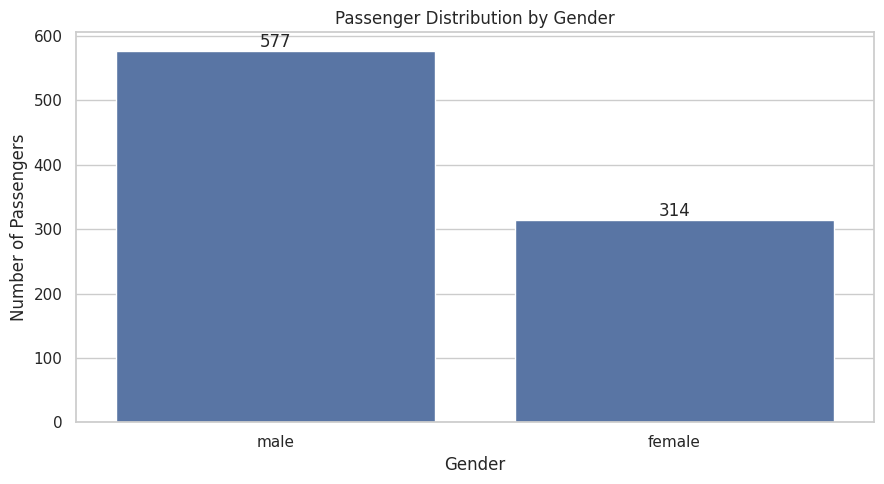

In [8]:
section("4. GENDER DISTRIBUTION")

sex_counts = df["Sex"].value_counts()

print(sex_counts)

plt.figure()
ax = sns.countplot(data=df, x="Sex")

plt.title("Passenger Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

for container in ax.containers:
    ax.bar_label(container)

show_plot()

print("\nINSIGHT:")
print(
    "There are more male than female passengers in the dataset. "
    "Passenger counts alone do not tell us whether gender is "
    "associated with survival, so survival rates must be compared."
)

## 6. SURVIVAL BY GENDER


5. SURVIVAL RATE BY GENDER
female: 74.2%
male: 18.9%

INSIGHT:
Female survival rate: 74.2%
Male survival rate: 18.9%
Gender shows one of the strongest observed associations with survival in this dataset.
This is an association in the data and does not prove that gender itself caused survival.


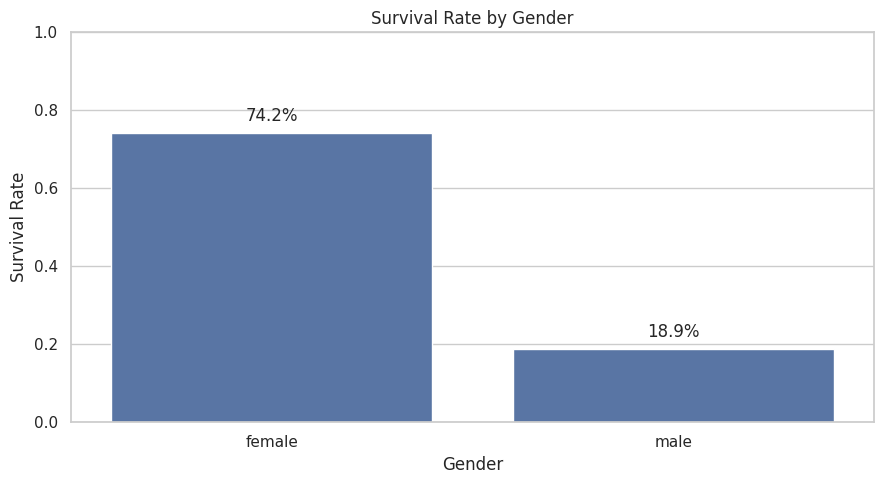

In [9]:
section("5. SURVIVAL RATE BY GENDER")

survival_by_sex = df.groupby("Sex")["Survived"].mean()

for sex, rate in survival_by_sex.items():
    print(f"{sex}: {rate * 100:.1f}%")

female_rate = survival_by_sex.get("female", np.nan)
male_rate = survival_by_sex.get("male", np.nan)

plt.figure()
ax = sns.barplot(
    x=survival_by_sex.index,
    y=survival_by_sex.values
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

for i, value in enumerate(survival_by_sex.values):
    ax.text(i, value + 0.03, f"{value * 100:.1f}%", ha="center")

show_plot()

print("\nINSIGHT:")
print(
    f"Female survival rate: {female_rate * 100:.1f}%"
)
print(
    f"Male survival rate: {male_rate * 100:.1f}%"
)
print(
    "Gender shows one of the strongest observed associations "
    "with survival in this dataset."
)
print(
    "This is an association in the data and does not prove "
    "that gender itself caused survival."
)

## 7. PASSENGER CLASS DISTRIBUTION


6. PASSENGER CLASS DISTRIBUTION
Class 1: 216 (24.2%)
Class 2: 184 (20.7%)
Class 3: 491 (55.1%)

INSIGHT:
Third-class passengers are the largest passenger group. The passenger classes are therefore not equally represented.


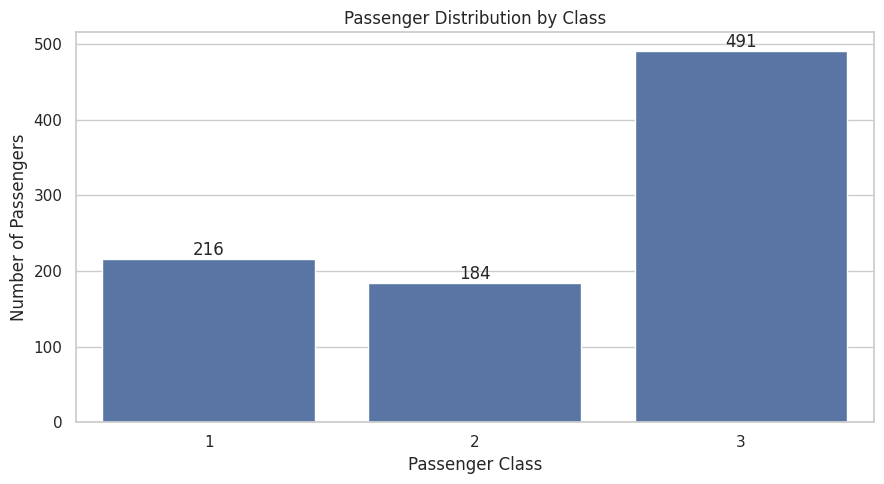

In [10]:
section("6. PASSENGER CLASS DISTRIBUTION")

class_counts = df["Pclass"].value_counts().sort_index()

for pclass, count in class_counts.items():
    print(
        f"Class {pclass}: {count} "
        f"({count / len(df) * 100:.1f}%)"
    )

plt.figure()
ax = sns.countplot(data=df, x="Pclass")

plt.title("Passenger Distribution by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

for container in ax.containers:
    ax.bar_label(container)

show_plot()

print("\nINSIGHT:")
print(
    "Third-class passengers are the largest passenger group. "
    "The passenger classes are therefore not equally represented."
)

## 8. SURVIVAL BY PASSENGER CLASS


7. SURVIVAL RATE BY PASSENGER CLASS
Class 1: 63.0%
Class 2: 47.3%
Class 3: 24.2%

INSIGHT:
Survival decreases substantially from first class to third class. Passenger class therefore has a strong association with survival.
Possible explanations include differences in ship location, access to evacuation areas, and socioeconomic circumstances.
The graph demonstrates association, not causation.


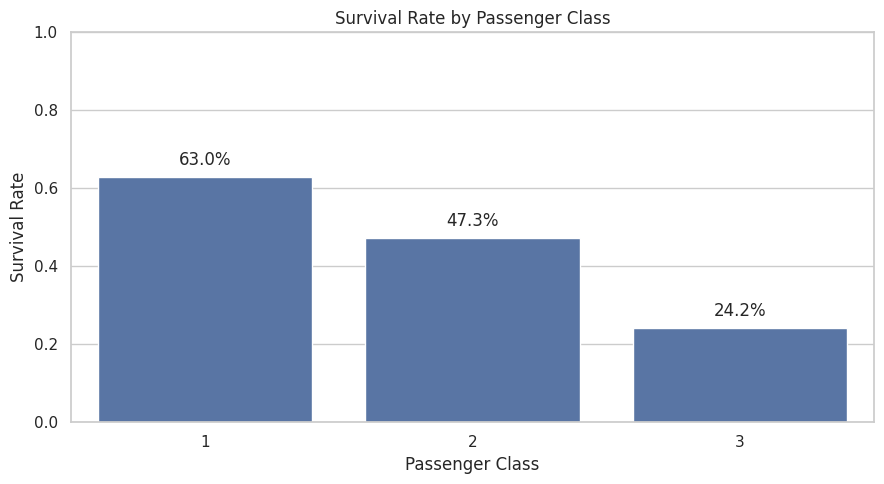

In [11]:
section("7. SURVIVAL RATE BY PASSENGER CLASS")

survival_by_class = df.groupby("Pclass")["Survived"].mean()

for pclass, rate in survival_by_class.items():
    print(f"Class {pclass}: {rate * 100:.1f}%")

plt.figure()
ax = sns.barplot(
    x=survival_by_class.index,
    y=survival_by_class.values
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

for i, value in enumerate(survival_by_class.values):
    ax.text(i, value + 0.03, f"{value * 100:.1f}%", ha="center")

show_plot()

print("\nINSIGHT:")
print(
    "Survival decreases substantially from first class to third class. "
    "Passenger class therefore has a strong association with survival."
)
print(
    "Possible explanations include differences in ship location, "
    "access to evacuation areas, and socioeconomic circumstances."
)
print(
    "The graph demonstrates association, not causation."
)

## 9. AGE DISTRIBUTION


8. AGE DISTRIBUTION
Known ages: 714
Missing ages: 177
Mean: 29.7
Median: 28.0
Minimum: 0.4
Maximum: 80.0

INSIGHT:
The passenger population is concentrated mainly around young and middle-aged adults. The graph excludes passengers whose age is missing.


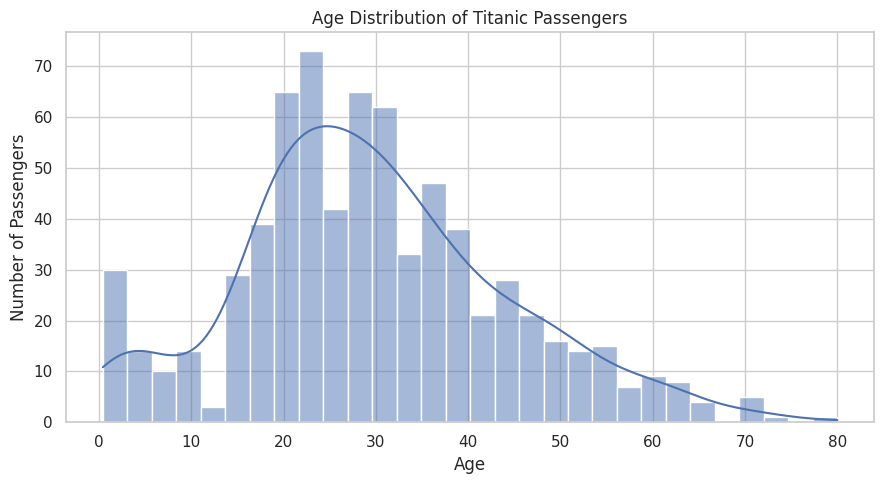

In [12]:
section("8. AGE DISTRIBUTION")

age = df["Age"].dropna()

print(f"Known ages: {len(age)}")
print(f"Missing ages: {df['Age'].isna().sum()}")
print(f"Mean: {age.mean():.1f}")
print(f"Median: {age.median():.1f}")
print(f"Minimum: {age.min():.1f}")
print(f"Maximum: {age.max():.1f}")

plt.figure()
sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Age Distribution of Titanic Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

show_plot()

print("\nINSIGHT:")
print(
    "The passenger population is concentrated mainly around "
    "young and middle-aged adults. The graph excludes passengers "
    "whose age is missing."
)

## 10. AGE VS SURVIVAL


9. AGE AND SURVIVAL
               mean  median  count
Survived                          
0         30.626179    28.0    424
1         28.343690    28.0    290

INSIGHT:
The age distributions of survivors and non-survivors overlap considerably. Therefore, age alone does not distinguish survival as clearly as gender or passenger class.


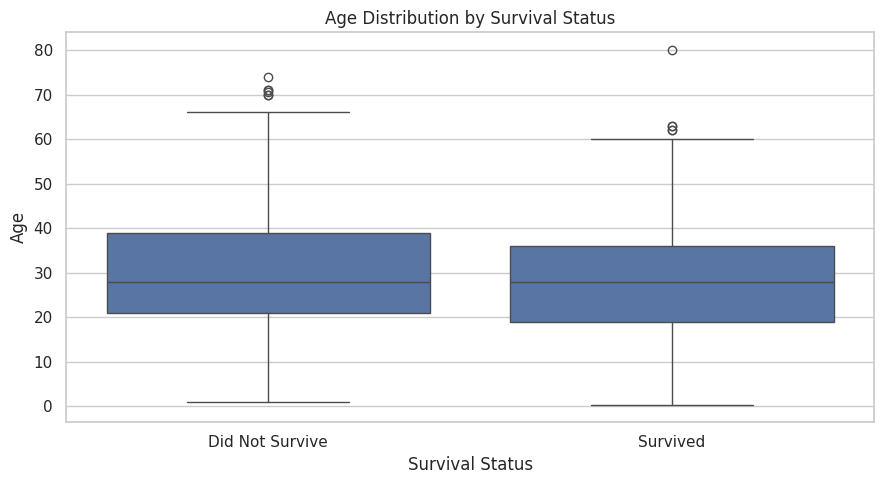

In [13]:
section("9. AGE AND SURVIVAL")

age_summary = df.groupby("Survived")["Age"].agg(
    ["mean", "median", "count"]
)

print(age_summary)

plt.figure()
sns.boxplot(
    data=df,
    x="Survived",
    y="Age"
)

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Age")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])

show_plot()

print("\nINSIGHT:")
print(
    "The age distributions of survivors and non-survivors overlap "
    "considerably. Therefore, age alone does not distinguish survival "
    "as clearly as gender or passenger class."
)

## 11. FARE DISTRIBUTION


10. FARE DISTRIBUTION
Mean fare: 32.20
Median fare: 14.45
Minimum fare: 0.00
Maximum fare: 512.33

INSIGHT:
Fare is strongly right-skewed. Most passengers paid relatively low fares, while a small number paid very high fares.


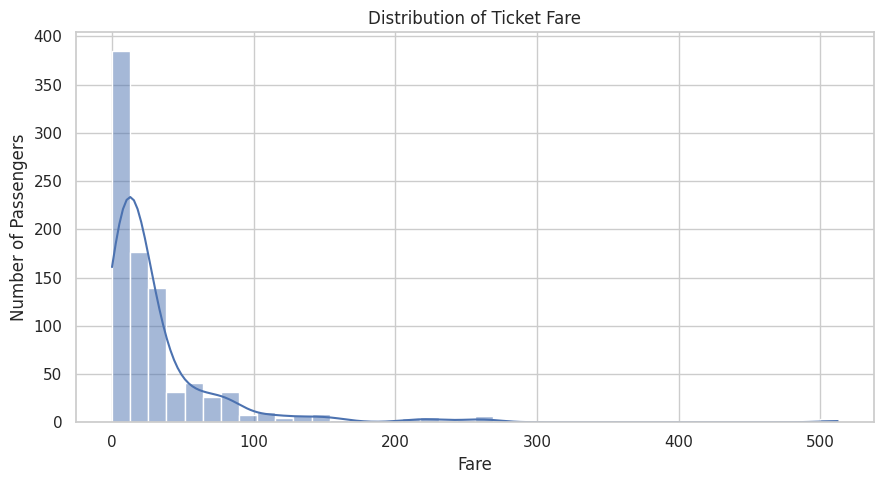

In [14]:
section("10. FARE DISTRIBUTION")

print(f"Mean fare: {df['Fare'].mean():.2f}")
print(f"Median fare: {df['Fare'].median():.2f}")
print(f"Minimum fare: {df['Fare'].min():.2f}")
print(f"Maximum fare: {df['Fare'].max():.2f}")

plt.figure()
sns.histplot(data=df, x="Fare", bins=40, kde=True)

plt.title("Distribution of Ticket Fare")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

show_plot()

print("\nINSIGHT:")
print(
    "Fare is strongly right-skewed. Most passengers paid relatively "
    "low fares, while a small number paid very high fares."
)

## 12. FARE VS SURVIVAL


11. FARE AND SURVIVAL
               mean  median
Survived                   
0         22.117887    10.5
1         48.395408    26.0

INSIGHT:
Survivors generally paid higher fares than non-survivors. However, fare is related to passenger class, so this relationship may partly reflect the relationship between class and survival.


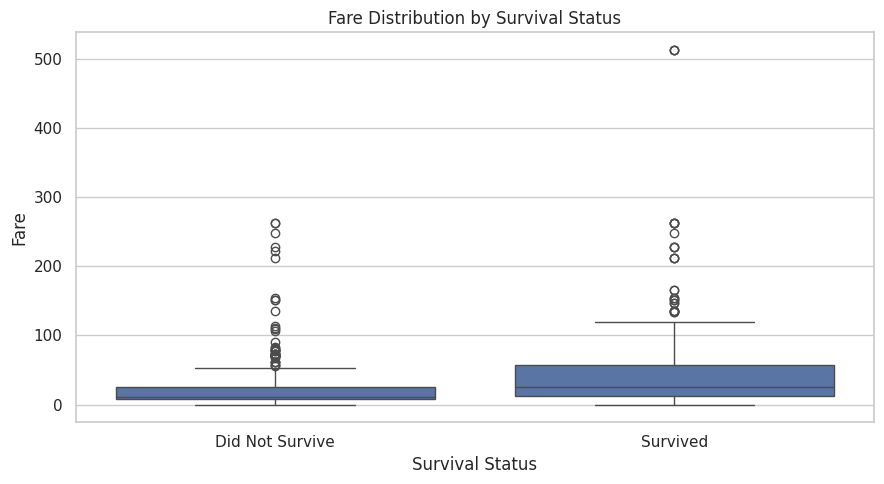

In [15]:
section("11. FARE AND SURVIVAL")

fare_summary = df.groupby("Survived")["Fare"].agg(
    ["mean", "median"]
)

print(fare_summary)

plt.figure()
sns.boxplot(
    data=df,
    x="Survived",
    y="Fare"
)

plt.title("Fare Distribution by Survival Status")
plt.xlabel("Survival Status")
plt.ylabel("Fare")
plt.xticks([0, 1], ["Did Not Survive", "Survived"])

show_plot()

print("\nINSIGHT:")
print(
    "Survivors generally paid higher fares than non-survivors. "
    "However, fare is related to passenger class, so this relationship "
    "may partly reflect the relationship between class and survival."
)

## 13. FAMILY SIZE


12. FAMILY SIZE
Mean family size: 1.90
Median family size: 1

INSIGHT:
Most passengers traveled alone or with a small number of family members. Very large families are relatively uncommon.


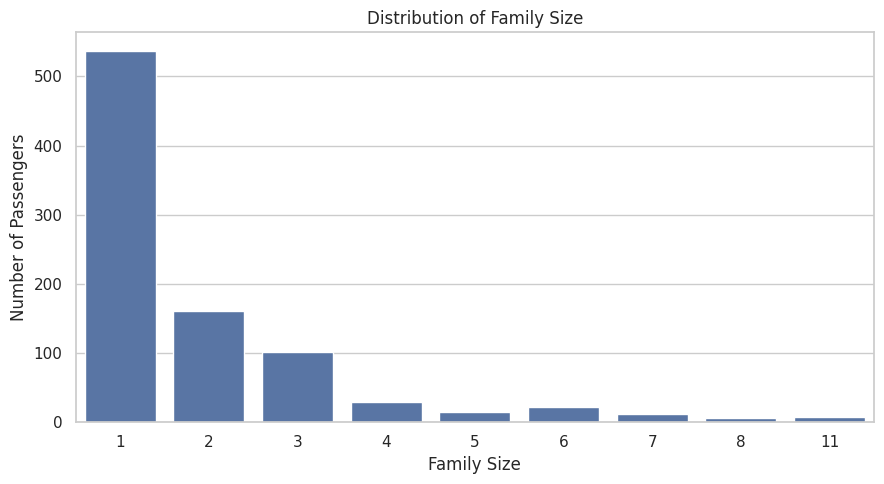

In [16]:
section("12. FAMILY SIZE")

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

print(f"Mean family size: {df['FamilySize'].mean():.2f}")
print(f"Median family size: {df['FamilySize'].median():.0f}")

plt.figure()
sns.countplot(data=df, x="FamilySize")

plt.title("Distribution of Family Size")
plt.xlabel("Family Size")
plt.ylabel("Number of Passengers")

show_plot()

print("\nINSIGHT:")
print(
    "Most passengers traveled alone or with a small number of "
    "family members. Very large families are relatively uncommon."
)

## 14. FAMILY SIZE VS SURVIVAL


13. FAMILY SIZE AND SURVIVAL

Survival rate and sample size:
            mean  count
FamilySize             
1           30.4  53700
2           55.3  16100
3           57.8  10200
4           72.4   2900
5           20.0   1500
6           13.6   2200
7           33.3   1200
8            0.0    600
11           0.0    700

INSIGHT:
Survival varies by family size, but very large family groups have relatively few observations. Their percentages should therefore be interpreted cautiously.


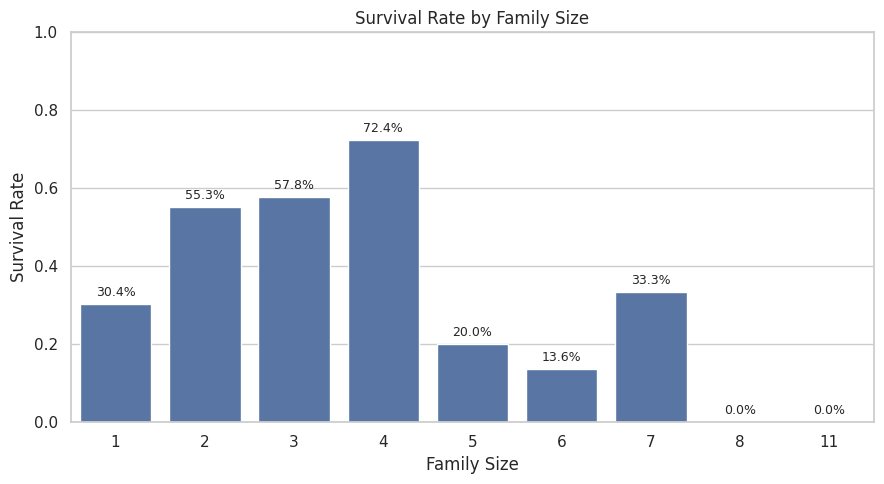

In [17]:
section("13. FAMILY SIZE AND SURVIVAL")

family_survival = df.groupby("FamilySize")["Survived"].agg(
    ["mean", "count"]
)

print("\nSurvival rate and sample size:")
print((family_survival * 100).round(1))

plt.figure()
ax = sns.barplot(
    x=family_survival.index,
    y=family_survival["mean"]
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

for i, value in enumerate(family_survival["mean"]):
    ax.text(
        i,
        value + 0.02,
        f"{value * 100:.1f}%",
        ha="center",
        fontsize=9
    )

show_plot()

print("\nINSIGHT:")
print(
    "Survival varies by family size, but very large family groups "
    "have relatively few observations. Their percentages should "
    "therefore be interpreted cautiously."
)

## 15. EMBARKATION AND SURVIVAL


14. SURVIVAL BY EMBARKATION PORT
C: 55.4%
Q: 39.0%
S: 33.7%

INSIGHT:
Survival rates differ between embarkation ports. However, the port itself should not be interpreted as a direct cause of survival because it may be associated with other variables such as passenger class and gender.


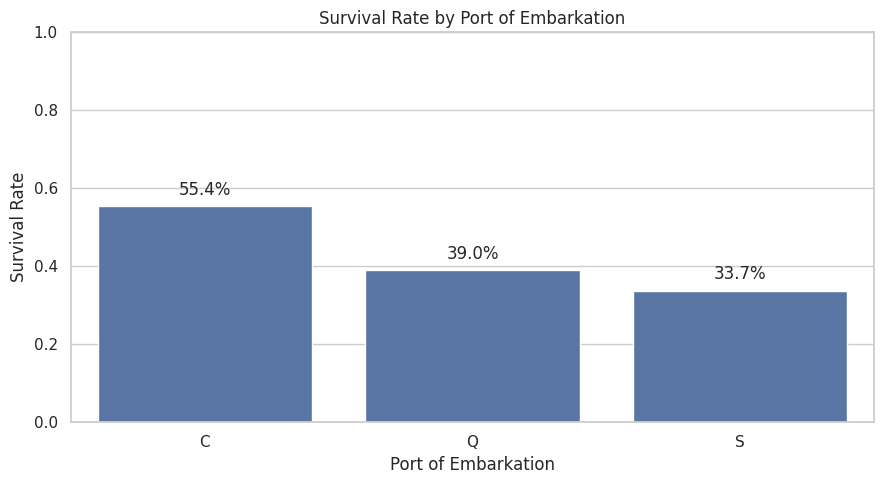

In [18]:
section("14. SURVIVAL BY EMBARKATION PORT")

embarked_survival = df.groupby("Embarked")["Survived"].mean()

for port, rate in embarked_survival.items():
    print(f"{port}: {rate * 100:.1f}%")

plt.figure()
ax = sns.barplot(
    x=embarked_survival.index,
    y=embarked_survival.values
)

plt.title("Survival Rate by Port of Embarkation")
plt.xlabel("Port of Embarkation")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

for i, value in enumerate(embarked_survival.values):
    ax.text(i, value + 0.03, f"{value * 100:.1f}%", ha="center")

show_plot()

print("\nINSIGHT:")
print(
    "Survival rates differ between embarkation ports. However, "
    "the port itself should not be interpreted as a direct cause "
    "of survival because it may be associated with other variables "
    "such as passenger class and gender."
)

## 16. CORRELATION HEATMAP


15. CORRELATION ANALYSIS

Correlation matrix:
          Survived  Pclass   Age  SibSp  Parch  Fare
Survived      1.00   -0.34 -0.08  -0.04   0.08  0.26
Pclass       -0.34    1.00 -0.37   0.08   0.02 -0.55
Age          -0.08   -0.37  1.00  -0.31  -0.19  0.10
SibSp        -0.04    0.08 -0.31   1.00   0.41  0.16
Parch         0.08    0.02 -0.19   0.41   1.00  0.22
Fare          0.26   -0.55  0.10   0.16   0.22  1.00

INSIGHT:
Pclass has a negative relationship with Survived, consistent with the finding that higher-numbered classes had lower survival.
Fare has a positive relationship with Survived, consistent with higher-fare passengers generally having higher survival.
Correlation measures linear association and does not imply causation.


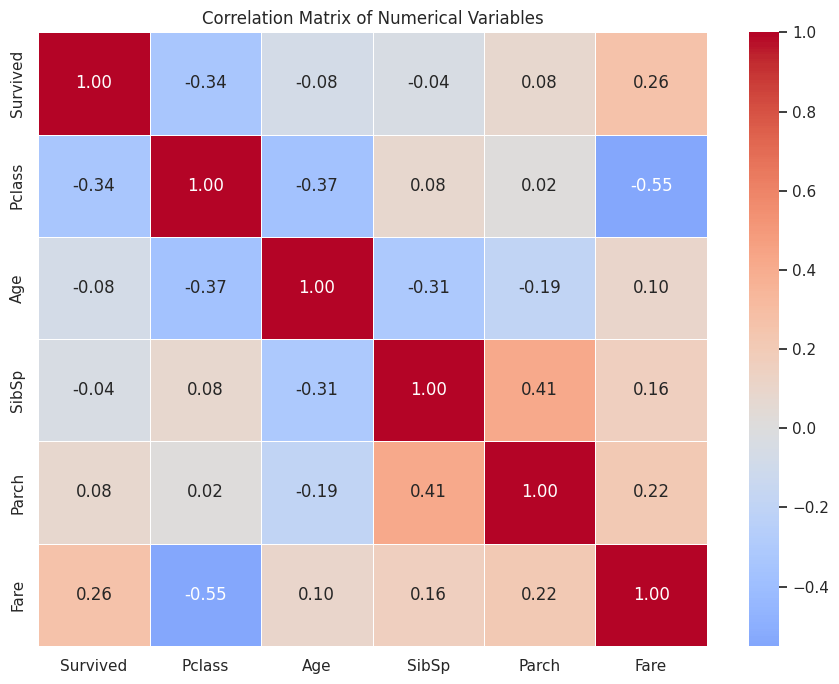

In [19]:
section("15. CORRELATION ANALYSIS")

numeric_columns = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

correlation = df[numeric_columns].corr()

print("\nCorrelation matrix:")
print(correlation.round(2))

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")

show_plot()

print("\nINSIGHT:")
print(
    "Pclass has a negative relationship with Survived, consistent "
    "with the finding that higher-numbered classes had lower survival."
)
print(
    "Fare has a positive relationship with Survived, consistent "
    "with higher-fare passengers generally having higher survival."
)
print(
    "Correlation measures linear association and does not imply causation."
)

## 17. MOST IMPORTANT MULTIVARIATE ANALYSIS


16. GENDER + PASSENGER CLASS + SURVIVAL

Survival rates (%):
Sex     female  male
Pclass              
1         96.8  36.9
2         92.1  15.7
3         50.0  13.5

INSIGHT:
This is one of the most important visualizations because it combines two major variables associated with survival.
The survival rate differs substantially across both gender and passenger class.
Examining multiple variables together provides more information than examining each variable independently.


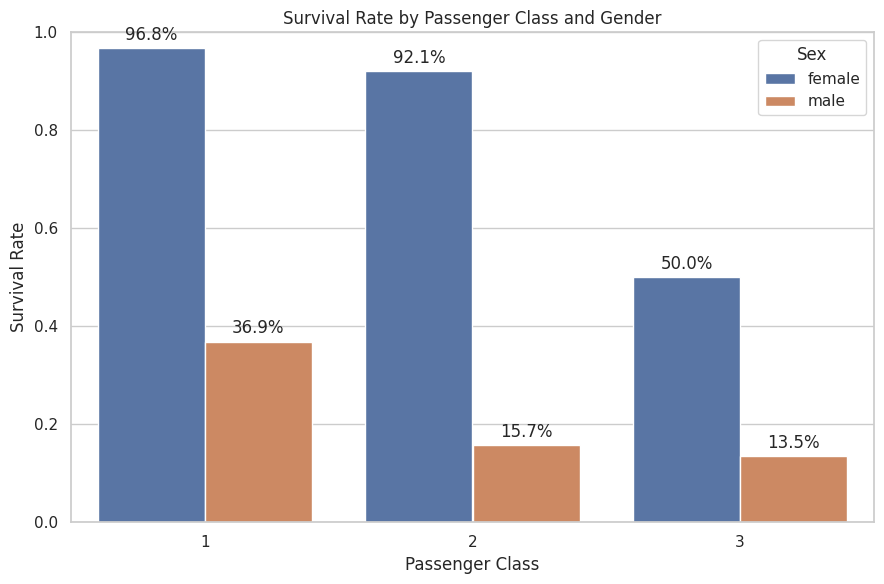

In [20]:
section("16. GENDER + PASSENGER CLASS + SURVIVAL")

combined = (
    df.groupby(["Pclass", "Sex"])["Survived"]
    .mean()
    .reset_index()
)

pivot = combined.pivot(
    index="Pclass",
    columns="Sex",
    values="Survived"
) * 100

print("\nSurvival rates (%):")
print(pivot.round(1))

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=combined,
    x="Pclass",
    y="Survived",
    hue="Sex"
)

plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)

for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        labels.append(
            "" if np.isnan(height)
            else f"{height * 100:.1f}%"
        )

    ax.bar_label(
        container,
        labels=labels,
        padding=3
    )

show_plot()

print("\nINSIGHT:")
print(
    "This is one of the most important visualizations because it "
    "combines two major variables associated with survival."
)
print(
    "The survival rate differs substantially across both gender "
    "and passenger class."
)
print(
    "Examining multiple variables together provides more information "
    "than examining each variable independently."
)

## 18. FINAL SUMMARY

In [21]:
section("17. FINAL EDA SUMMARY")

print(
    f"""
Dataset:
- {len(df)} passengers
- {df.shape[1]} original columns

Data quality:
- Cabin contains a very large amount of missing data.
- Age contains substantial missing data.
- Embarked has very few missing values.

Survival:
- Overall survival rate: {survival_rate * 100:.1f}%

Gender:
- Female survival rate: {female_rate * 100:.1f}%
- Male survival rate: {male_rate * 100:.1f}%

Passenger class:
- 1st class: {survival_by_class.get(1, np.nan) * 100:.1f}%
- 2nd class: {survival_by_class.get(2, np.nan) * 100:.1f}%
- 3rd class: {survival_by_class.get(3, np.nan) * 100:.1f}%

Main findings:
1. Gender has a strong association with survival.
2. Passenger class has a strong association with survival.
3. Higher fares are associated with higher survival rates.
4. Age provides additional information but has a weaker relationship.
5. Family size shows variation, but large-family groups may have
   small sample sizes.
6. Missing data, especially Cabin and Age, must be considered.

Overall:
The most important variables to investigate further are Sex and
Pclass, followed by Fare, Age, and family-related variables.

Important:
EDA identifies patterns and associations. It does not prove that
a variable directly caused a passenger to survive.
"""
)

print("=" * 75)
print("EDA COMPLETE")
print("=" * 75)


17. FINAL EDA SUMMARY

Dataset:
- 891 passengers
- 13 original columns

Data quality:
- Cabin contains a very large amount of missing data.
- Age contains substantial missing data.
- Embarked has very few missing values.

Survival:
- Overall survival rate: 38.4%

Gender:
- Female survival rate: 74.2%
- Male survival rate: 18.9%

Passenger class:
- 1st class: 63.0%
- 2nd class: 47.3%
- 3rd class: 24.2%

Main findings:
1. Gender has a strong association with survival.
2. Passenger class has a strong association with survival.
3. Higher fares are associated with higher survival rates.
4. Age provides additional information but has a weaker relationship.
5. Family size shows variation, but large-family groups may have
   small sample sizes.
6. Missing data, especially Cabin and Age, must be considered.

Overall:
The most important variables to investigate further are Sex and
Pclass, followed by Fare, Age, and family-related variables.

Important:
EDA identifies patterns and associations. 